# Loading

In [10]:
import pandas as pd
import json

json_file_path = '/content/jstris_dynam1c.json'

with open(json_file_path, 'r') as f:
    json_data = json.load(f)


In [11]:
df_sprint = pd.DataFrame(json_data['sprint_40l']['games'])
df_sprint["mode"] = "sprint"
display(df_sprint.head())

df_ultra = pd.DataFrame(json_data['ultra']['games'])
df_ultra["mode"] = "ultra"
display(df_ultra.head())

,id,gametime,timestamp,blocks,pps,finesse,ppb,has_replay,replay_url,mode
0,63636888,29.071,2022-12-12T16:10:14+00:00,101,3.47,5,None,True,https://jstris.jezevec10.com/replay/63636888,sprint
1,61603213,29.501,2022-10-29T15:28:01+00:00,103,3.49,0,None,True,https://jstris.jezevec10.com/replay/61603213,sprint
2,61783149,29.704,2022-11-02T13:03:33+00:00,102,3.43,1,None,True,https://jstris.jezevec10.com/replay/61783149,sprint
3,62008858,29.734,2022-11-07T09:07:28+00:00,101,3.40,0,None,True,https://jstris.jezevec10.com/replay/62008858,sprint
4,74581769,29.791,2023-09-10T11:08:24+00:00,102,3.42,1,None,True,https://jstris.jezevec10.com/replay/74581769,sprint


,id,gametime,timestamp,blocks,pps,finesse,ppb,has_replay,replay_url,mode
0,93938277,107918.0,2025-03-11T16:42:41+00:00,352,2.93,35,306.59,True,https://jstris.jezevec10.com/replay/93938277,ultra
1,93964630,103259.0,2025-03-12T13:13:15+00:00,341,2.84,35,302.81,True,https://jstris.jezevec10.com/replay/93964630,ultra
2,85122875,101334.0,2024-06-15T21:57:19+00:00,348,2.90,25,291.19,True,https://jstris.jezevec10.com/replay/85122875,ultra
3,93971178,96091.0,2025-03-12T16:48:51+00:00,319,2.66,42,301.23,True,https://jstris.jezevec10.com/replay/93971178,ultra
4,71064760,94833.0,2023-06-07T14:32:25+00:00,323,2.69,38,293.60,True,https://jstris.jezevec10.com/replay/71064760,ultra


PPB means points per piece, which in ultra measures how efficient you are in scoring. PPS means pieces per second, which measures how fast you are playing. Finesse is the number of finesse mistakes (unnecessary keypresses) you made. Gametime means score for ultra (not a thing about tetris, it's just a peculiarity of how I extracted the data).

In [12]:
df_combined = pd.concat([df_sprint, df_ultra], ignore_index=True)
df_combined['timestamp'] = pd.to_datetime(df_combined['timestamp'])
df_combined = df_combined.sort_values(by='timestamp')
display(df_combined.head())

/tmp/ipykernel_17811/2529952908.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat([df_sprint, df_ultra], ignore_index=True)


,id,gametime,timestamp,blocks,pps,finesse,ppb,has_replay,replay_url,mode
1093,33463798,14927.000,2021-04-26 20:55:26+00:00,154,1.28,127,96.93,True,https://jstris.jezevec10.com/replay/33463798,ultra
978,33508124,54.647,2021-04-27 15:43:06+00:00,101,1.85,43,NaN,True,https://jstris.jezevec10.com/replay/33508124,sprint
1092,33509696,24383.000,2021-04-27 16:12:56+00:00,175,1.46,113,139.33,True,https://jstris.jezevec10.com/replay/33509696,ultra
985,34419109,55.939,2021-05-13 22:47:28+00:00,104,1.86,70,NaN,False,None,sprint
990,34419343,58.077,2021-05-13 22:53:07+00:00,102,1.76,56,NaN,False,None,sprint


In [13]:
df_combined['seq'] = range(1, len(df_combined)+1)
df_combined['adj_time'] = df_combined['timestamp'].diff().dt.total_seconds()
df_combined.loc[df_combined['seq'] == 1, 'adj_time'] = 0
df_combined['adj_time'] = (df_combined['adj_time'] ** 0.5).cumsum()
display(df_combined.head())

,id,gametime,timestamp,blocks,pps,finesse,ppb,has_replay,replay_url,mode,seq,adj_time
1093,33463798,14927.000,2021-04-26 20:55:26+00:00,154,1.28,127,96.93,True,https://jstris.jezevec10.com/replay/33463798,ultra,1,0.000000
978,33508124,54.647,2021-04-27 15:43:06+00:00,101,1.85,43,NaN,True,https://jstris.jezevec10.com/replay/33508124,sprint,2,260.115359
1092,33509696,24383.000,2021-04-27 16:12:56+00:00,175,1.46,113,139.33,True,https://jstris.jezevec10.com/replay/33509696,ultra,3,302.423751
985,34419109,55.939,2021-05-13 22:47:28+00:00,104,1.86,70,NaN,False,None,sprint,4,1488.202819
990,34419343,58.077,2021-05-13 22:53:07+00:00,102,1.76,56,NaN,False,None,sprint,5,1506.614772


# Plotting

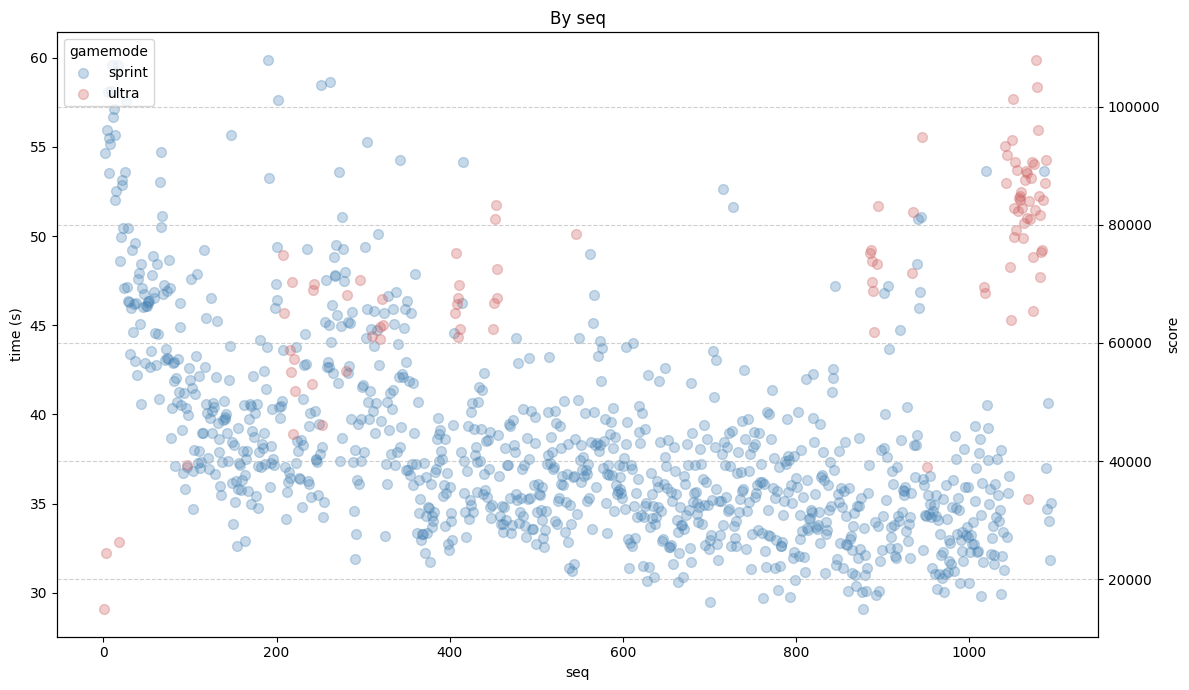

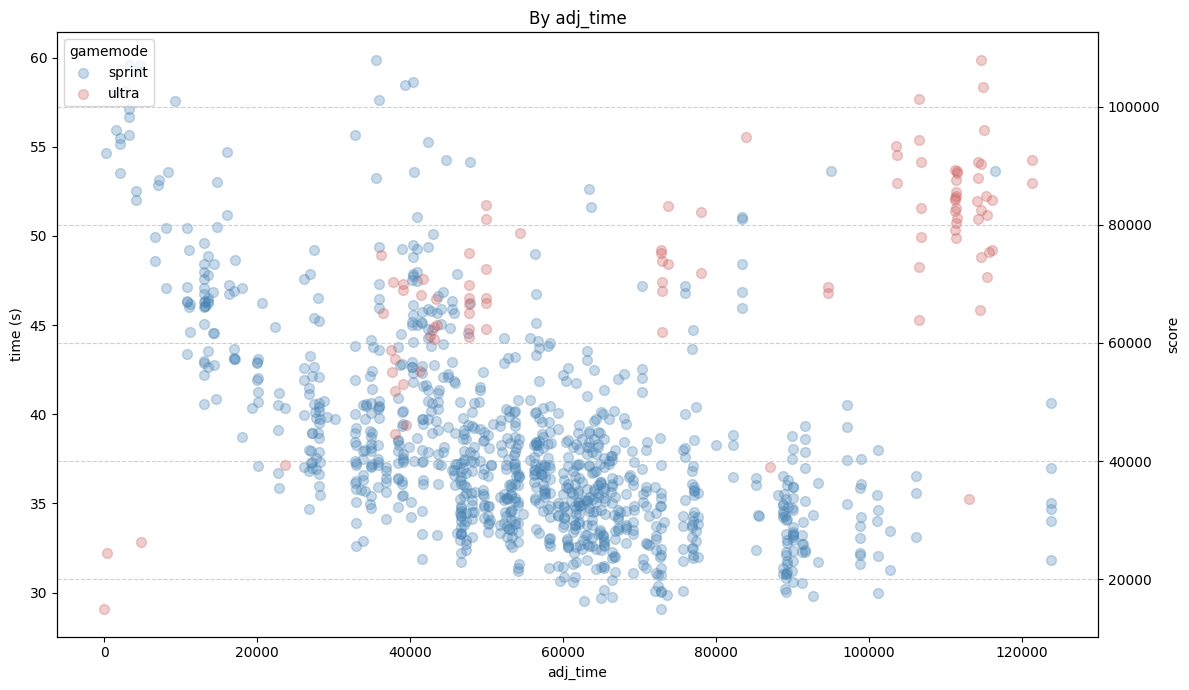

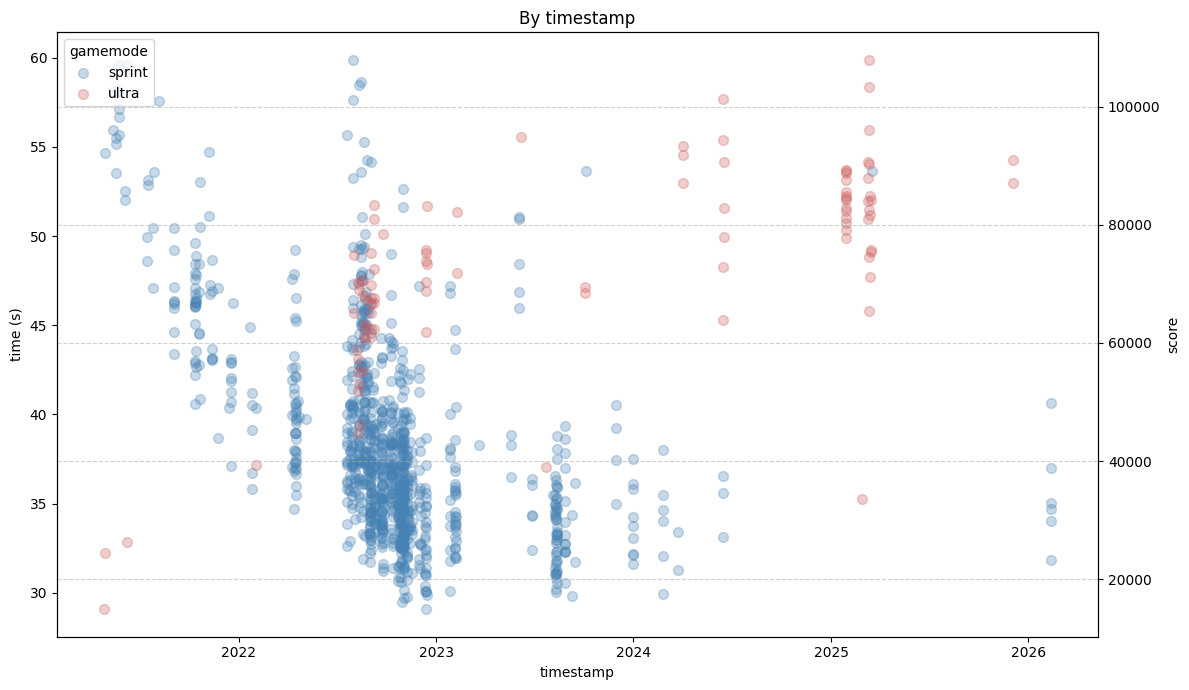

In [14]:
import matplotlib.pyplot as plt

def plot_against(col):
  plt.figure(figsize=(12, 7))

  ax1 = plt.gca()
  sprint_df = df_combined[df_combined['mode'] == 'sprint']
  ax1.scatter(sprint_df[col], sprint_df['gametime'], color='steelblue', s=50, alpha=0.3, label='sprint')
  ax1.set_xlabel(col)
  ax1.set_ylabel('time (s)')
  ax1.tick_params(axis='y')

  ax2 = ax1.twinx()
  ultra_df = df_combined[df_combined['mode'] == 'ultra']
  ax2.scatter(ultra_df[col], ultra_df['gametime'], color='indianred', s=50, alpha=0.3, label='ultra')
  ax2.set_ylabel('score')
  ax2.tick_params(axis='y')

  plt.title('By ' + col)

  lines1, labels1 = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax2.legend(lines1 + lines2, labels1 + labels2, title='gamemode', loc='upper left')

  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

plot_against("seq")
plot_against("adj_time")
plot_against("timestamp")

Since players usually have periods of concentrated play, the plot by timestamp looks like it consists of a collection of vertical spikes, where the verticality is the variation in the score/time. This is why I opted to use adjusted time, where the time is calculated using the square root of the number of seconds since the last game. This way, the data is less sparse.

# EDA

## Data description

For context, the finesse column is the number of finesse mistakes made in that game, where a finesse mistake is an unnecessary keypress. This means that usually playing with better finesse means you play faster. Lower is better.

In [15]:
sprint_df = df_combined[df_combined['mode'] == 'sprint'].copy()
ultra_df = df_combined[df_combined['mode'] == 'ultra'].copy()

print("Sprint (gametime = time (s), lower is better)")
display(sprint_df[['gametime', 'pps', 'finesse', 'blocks']].describe())

print("Ultra (gametime = score, higher is better)")
display(ultra_df[['gametime', 'pps', 'finesse', 'blocks', 'ppb']].describe())

Sprint (gametime = time (s), lower is better)


,gametime,pps,finesse,blocks
count,998.000000,998.000000,998.000000,998.000000
mean,38.224932,2.767595,11.893788,104.031062
std,5.537665,0.330406,17.660931,3.355565
min,29.071000,1.710000,0.000000,100.000000
25%,34.445250,2.582500,0.000000,102.000000
50%,36.976500,2.810000,2.000000,103.000000
75%,40.446750,3.000000,17.000000,105.000000
max,59.882000,3.490000,86.000000,128.000000


Ultra (gametime = score, higher is better)


,gametime,pps,finesse,blocks,ppb
count,96.000000,96.000000,96.000000,96.000000,96.000000
mean,72903.020833,2.262083,52.375000,271.395833,266.241667
std,16822.706398,0.380540,20.618464,45.673320,34.027951
min,14927.000000,0.970000,16.000000,116.000000,96.930000
25%,65035.000000,2.105000,38.750000,252.500000,253.152500
50%,74731.000000,2.340000,50.500000,281.000000,272.825000
75%,84181.750000,2.502500,64.000000,300.250000,286.207500
max,107918.000000,2.930000,127.000000,352.000000,307.250000


## Score, time, finesse and pps histograms

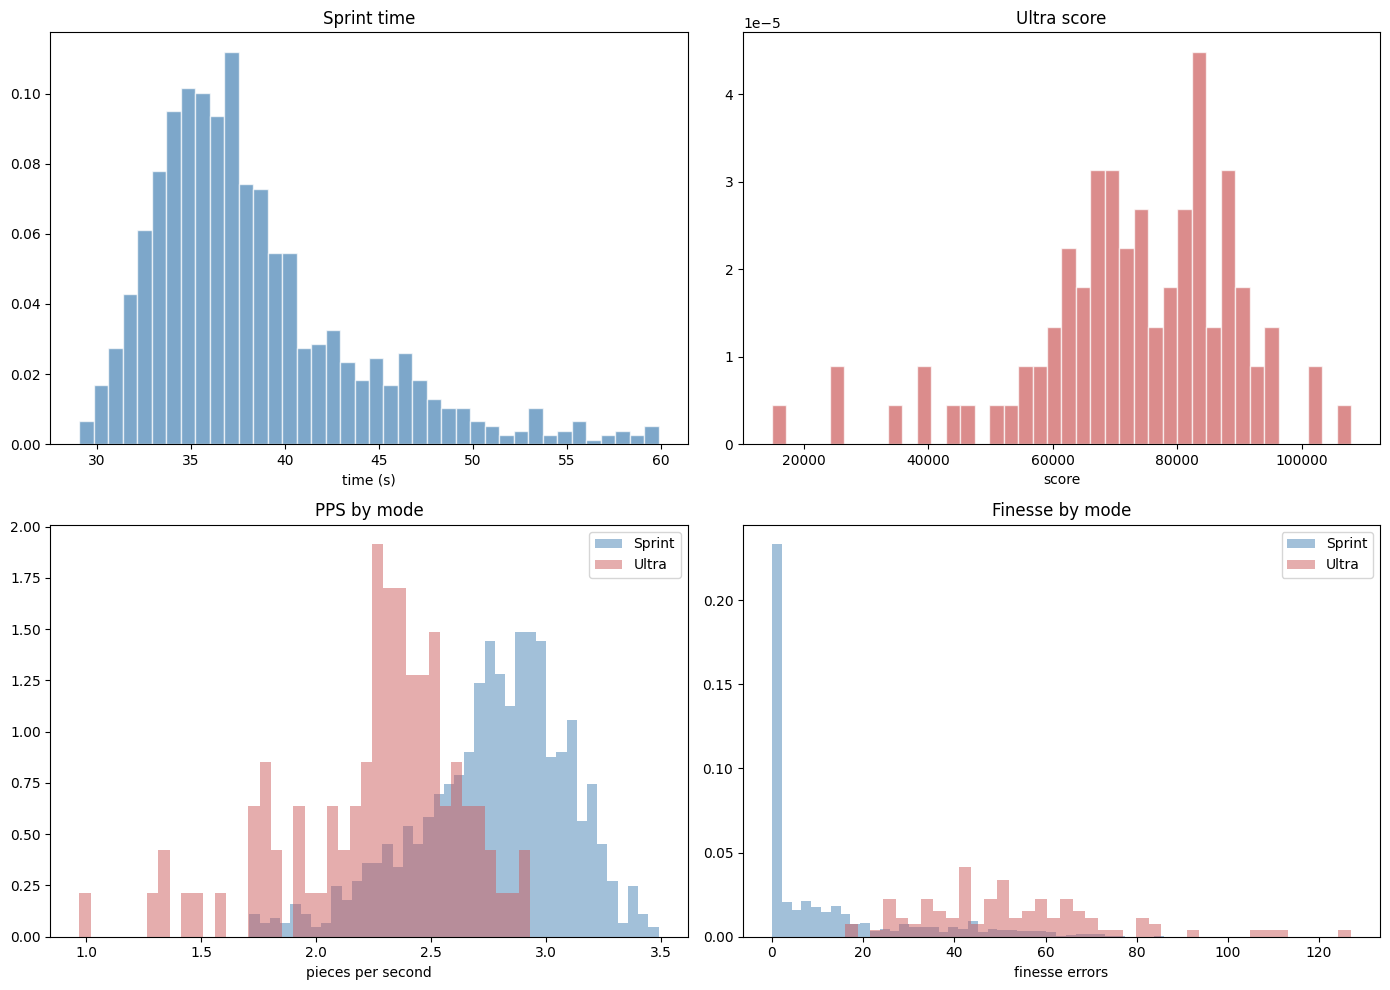

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(sprint_df['gametime'], bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Sprint time')
axes[0, 0].set_xlabel('time (s)')

axes[0, 1].hist(ultra_df['gametime'], bins=40, density=True, alpha=0.7, color='indianred', edgecolor='white')
axes[0, 1].set_title('Ultra score')
axes[0, 1].set_xlabel('score')

axes[1, 0].hist(sprint_df['pps'], bins=40, density=True, alpha=0.5, color='steelblue', label='Sprint')
axes[1, 0].hist(ultra_df['pps'], bins=40, density=True, alpha=0.5, color='indianred', label='Ultra')
axes[1, 0].set_title('PPS by mode')
axes[1, 0].set_xlabel('pieces per second')
axes[1, 0].legend()

axes[1, 1].hist(sprint_df['finesse'], bins=40, density=True, alpha=0.5, color='steelblue', label='Sprint')
axes[1, 1].hist(ultra_df['finesse'], bins=40, density=True, alpha=0.5, color='indianred', label='Ultra')
axes[1, 1].set_title('Finesse by mode')
axes[1, 1].set_xlabel('finesse errors')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Correlation matrix

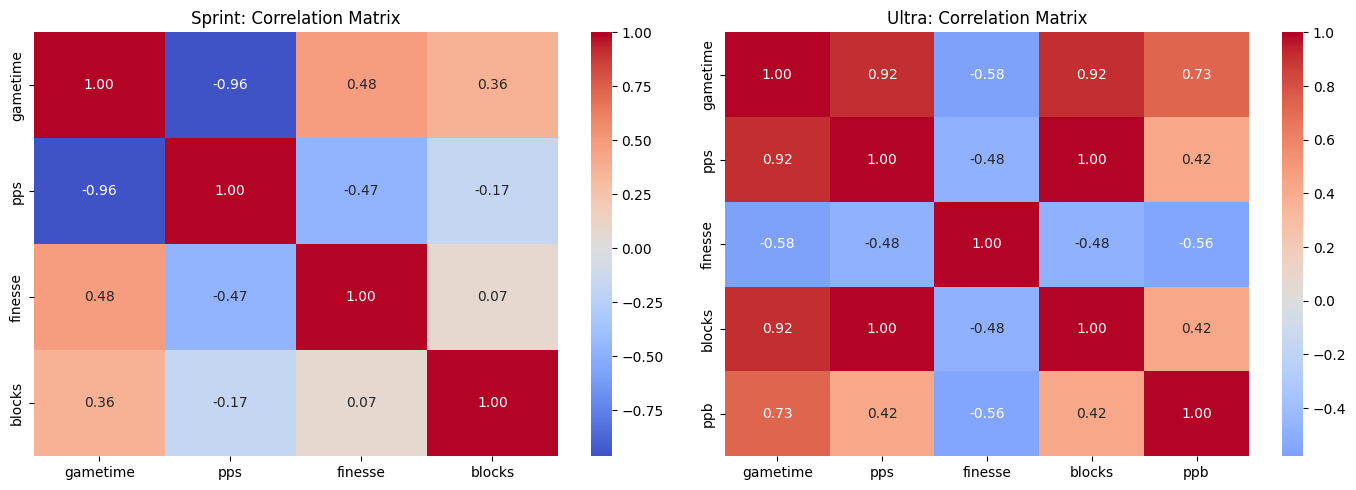

In [17]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sprint_corr = sprint_df[['gametime', 'pps', 'finesse', 'blocks']].corr()
sns.heatmap(sprint_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Sprint: Correlation Matrix')

ultra_corr = ultra_df[['gametime', 'pps', 'finesse', 'blocks', 'ppb']].dropna().corr()
sns.heatmap(ultra_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Ultra: Correlation Matrix')

plt.tight_layout()
plt.show()

For sprint, this is unsurprising. PPS nearly entirely determines sprint performance, since sprint is just "how much time does it take you to clear 40 lines".

For ultra, something interesting to note is that PPS has a better correlation with score than PPB (pieces per block) does. This is, when I think about it in hindsight, to be expected since ultra is limited by 2 minutes and making a few low-scoring clears here and there won't affect your time much but will affect your score. Although, it is a bit saddening that simply just playing faster makes you a better ultra player.

# Hypothesis testing
I found it more appropriate to use non-parametric tests for this dataset. I have no good assumptions to make about the distribution of the data or the mean and variance and such. So my options are Mann-Whitney, Wilcoxon, and Kruskal. Since Kruskal is for >2 groups which I don't have in most contexts, I can use either Mann-Whitney U or Wilcoxon for my hypothesis testing.

An additional thing to note is that since players usually play either ultra or sprint in some given time period, the ultra vs sprint comparisons may potentially be misleading.

## Sprint vs ultra PPS (Wilcoxon)
When paired by months, am I faster in ultra or sprint?

In [18]:
from scipy import stats

df_combined['year_month'] = df_combined['timestamp'].dt.to_period('M')

monthly = df_combined.groupby(['year_month', 'mode'])['pps'].median().unstack()
monthly = monthly.dropna()

w_stat, p_value = stats.wilcoxon(monthly['sprint'], monthly['ultra'])
print(f'Month count: {len(monthly)}')
print(f'Median monthly sprint pps: {monthly["sprint"].median():.4f}')
print(f'Median monthly ultra pps: {monthly["ultra"].median():.4f}')
print(f'W-statistic: {w_stat:.4f}')
print(f'p-value: {p_value:.6f}')

Month count: 11
Median monthly sprint pps: 2.5900
Median monthly ultra pps: 2.2900
W-statistic: 6.0000
p-value: 0.013672


/tmp/ipykernel_17811/3431179646.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_combined['year_month'] = df_combined['timestamp'].dt.to_period('M')


p<0.05, so I do indeed play faster in sprint than I do in ultra. This is explained by the fact that in ultra, players need to think more about where to place their pieces, since making high-scoring clears is more complicated than just trying to clear any lines like in sprint.

## Sprint vs ultra finesse (Wilcoxon)

In [19]:
monthly = df_combined.groupby(['year_month', 'mode'])['finesse'].median().unstack()
monthly = monthly.dropna()

w_stat, p_value = stats.wilcoxon(monthly['sprint'], monthly['ultra'])
print(f'Median monthly sprint finesse: {monthly["sprint"].median():.4f}')
print(f'Median monthly ultra finesse: {monthly["ultra"].median():.4f}')
print(f'W-statistic: {w_stat:.4f}')
print(f'p-value: {p_value:.6f}')

Median monthly sprint finesse: 14.0000
Median monthly ultra finesse: 51.0000
W-statistic: 0.0000
p-value: 0.000977


And I do move pieces more efficiently in sprint, which is also unsurprising, since unless you top out (die) clearing lines faster is equivalent to placing pieces faster (not factoring in how many redundant pieces are placed, i.e. having more than 103 blocks placed by the end of the sprint game).

## Have I been improving? (Mann-whitney)

In [20]:
q1 = sprint_df['seq'].quantile(0.80)
q2 = sprint_df['seq'].quantile(0.90)
second_last = sprint_df[(sprint_df['seq'] > q1) & (sprint_df['seq'] <= q2)]['gametime']
last = sprint_df[sprint_df['seq'] > q2]['gametime']
u_stat, p_value = stats.mannwhitneyu(last, second_last, alternative='less')
print(f'U-statistic: {u_stat:.4f}')
print(f'p-value: {p_value:.6f}')

U-statistic: 4260.5000
p-value: 0.035485


Apparently yes, my last 10% of games are better than my second to last 10% of games.